<a href="https://colab.research.google.com/github/ScholarlyInsane/ml-practice/blob/main/HousePrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/data.csv')

In [ ]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [ ]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [ ]:
df.describe(include='O')

,date,street,city,statezip,country
count,4600,4600,4600,4600,4600
unique,70,4525,44,77,1
top,2014-06-23 00:00:00,2520 Mulberry Walk NE,Seattle,WA 98103,USA
freq,142,4,1573,148,4600


In [ ]:
df.shape

(4600, 18)

In [ ]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


Used to categorize the columns of your DataFrame (df) into two lists: num for numerical columns and cat for categorical (object) columns.

In [ ]:
num = []
cat = []

for cols in df.columns:
    if df[cols].dtype == 'O':
        cat.append(cols)
    else:
        num.append(cols)

In [ ]:
df.nunique()

,0
date,70
price,1741
bedrooms,10
bathrooms,26
sqft_living,566
sqft_lot,3113
floors,6
waterfront,2
view,5
condition,5


In [ ]:
df=df.drop(columns=['date','street','city','statezip','country'])

In [ ]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992


Calculates a new feature called house_age and adds it as a new column to your DataFrame df.

In [ ]:
df['house_age'] = 2026 - df['yr_renovated']- df['yr_built']

In [ ]:
df = df[df['house_age']>0]
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,house_age
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,105
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,60
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,63
6,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,50
7,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,37


Plotting

<Axes: xlabel='sqft_living', ylabel='price'>

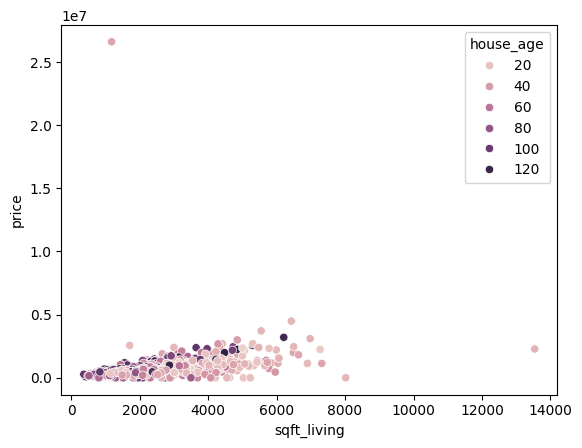

In [ ]:
sns.scatterplot(df,x= 'sqft_living', y = 'price',hue='house_age')

<Axes: xlabel='house_age', ylabel='price'>

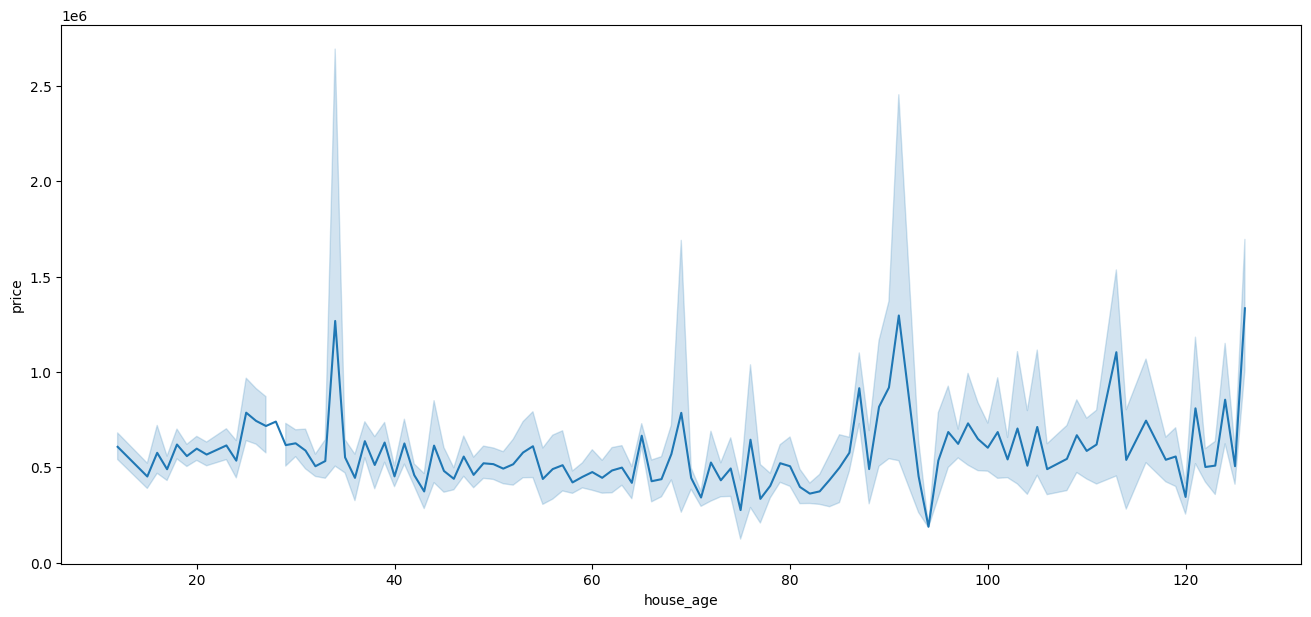

In [ ]:
plt.figure(figsize = (16,7))
sns.lineplot(df,x = 'house_age', y = 'price')

/tmp/ipykernel_214/2651927861.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x = 'floors', y = 'price',palette = 'Set2')


<Axes: xlabel='floors', ylabel='price'>

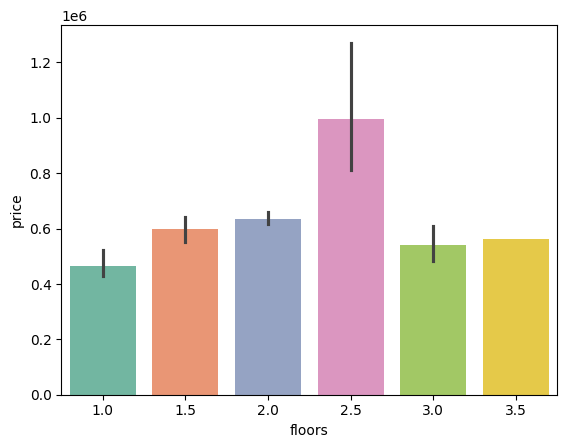

In [ ]:
sns.barplot(df, x = 'floors', y = 'price',palette = 'Set2')

/tmp/ipykernel_214/1452925834.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x = 'waterfront', y = 'price' , palette = 'Set2')


<Axes: xlabel='waterfront', ylabel='price'>

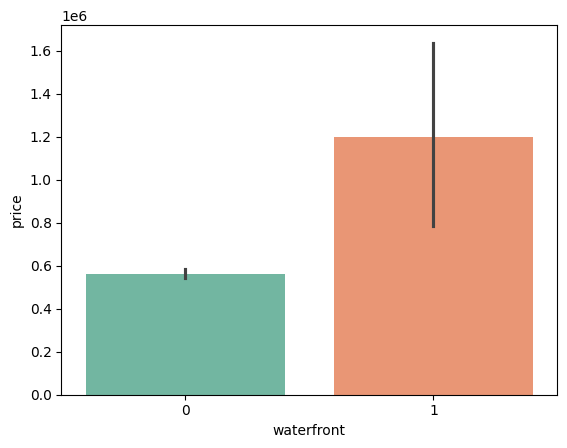

In [ ]:
sns.barplot(df, x = 'waterfront', y = 'price' , palette = 'Set2')

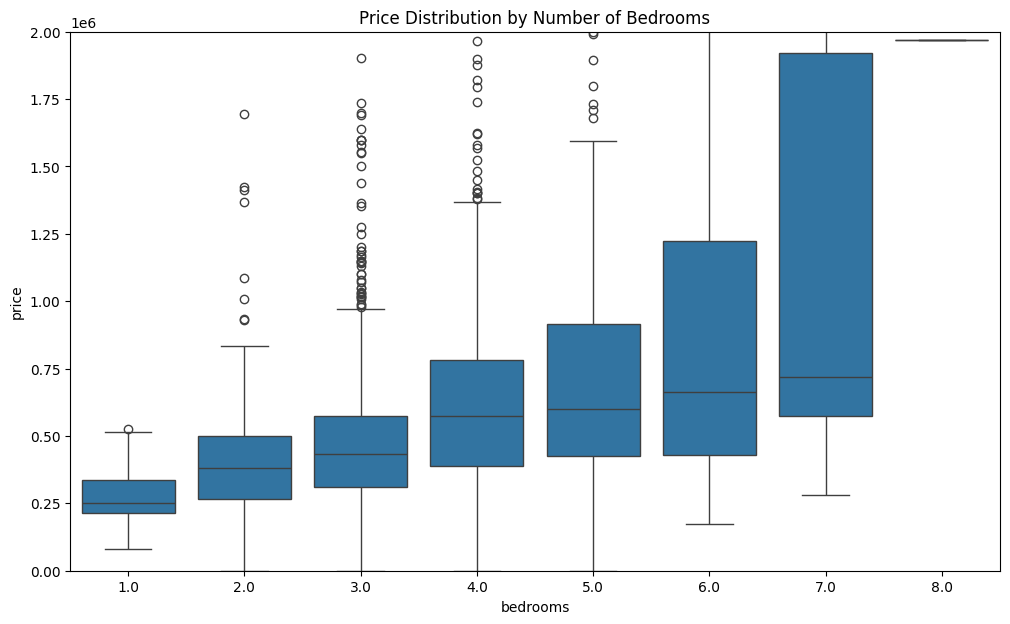

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(df , x = 'bedrooms' , y = 'price')
plt.title('Price Distribution by Number of Bedrooms')
plt.ylim(0, 2000000) # Setting y-axis limit to focus on typical price range
plt.show()

<Axes: >

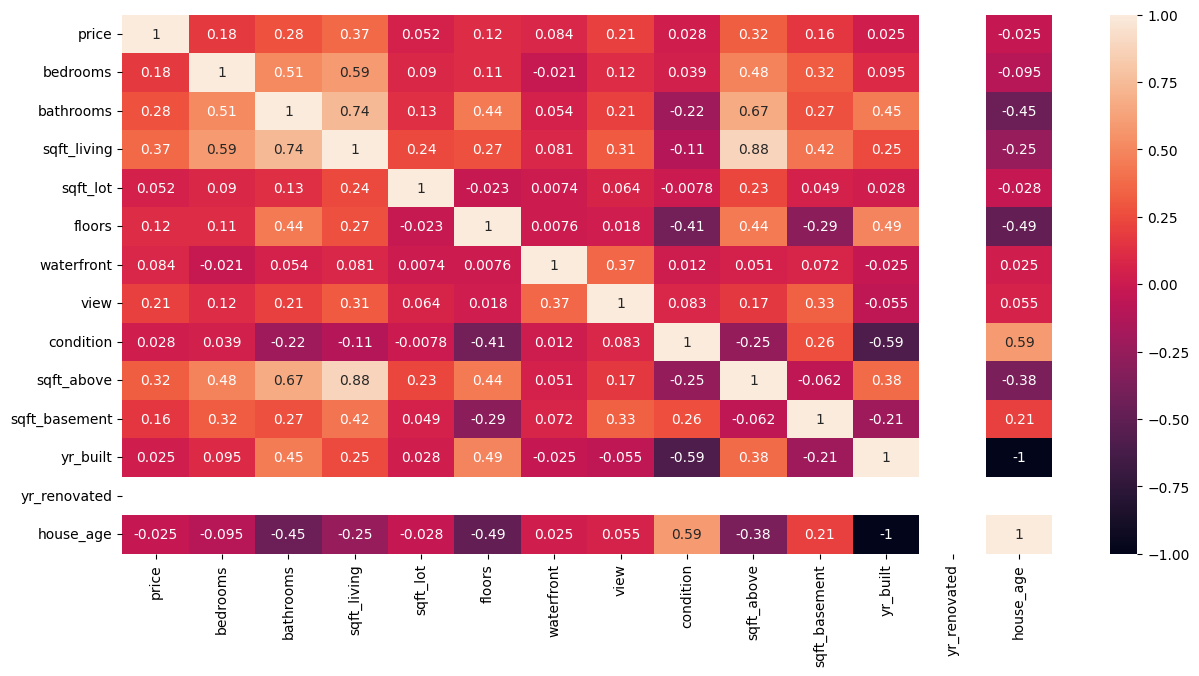

In [ ]:
num  = df.select_dtypes(include = 'number')
plt.figure(figsize = (15,7))
sns.heatmap(num.corr(),annot = True)

<Axes: xlabel='yr_built', ylabel='price'>

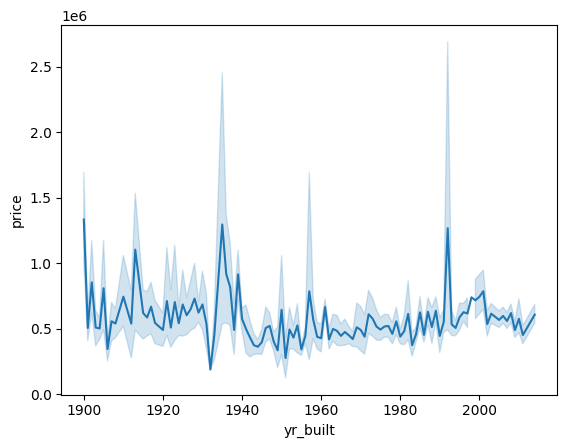

In [ ]:
sns.lineplot(df, x = 'yr_built' , y = 'price')

The line plot of price against yr_built generally shows an upward trend. This suggests that newer houses (those built more recently) tend to have higher prices.

<Axes: xlabel='condition'>

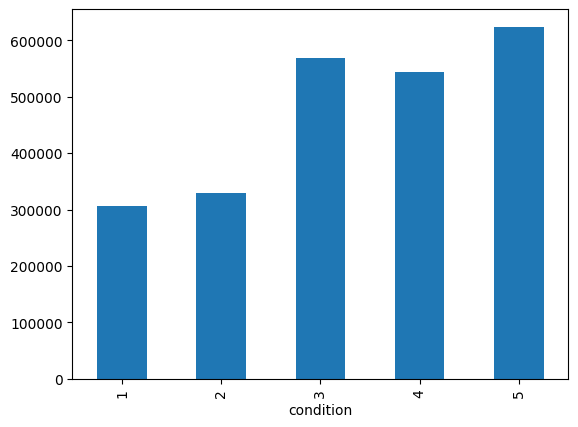

In [ ]:
df.groupby('condition')['price'].mean().plot(kind = 'bar')

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2188, 13)
X_test shape: (547, 13)
y_train shape: (2188,)
y_test shape: (547,)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
print("Predictions made on X_test.")

Predictions made on X_test.


In [ ]:
threshold_median = y_train.median()
y_test_bin = (y_test >= threshold_median).astype(int)
y_pred_bin = (y_pred >= threshold_median).astype(int)

print(f"Median threshold (y_train): {threshold_median}")
print("First 5 binarized actual values (y_test_bin):")
print(y_test_bin.head())
print("First 5 binarized predicted values (y_pred_bin):")
print(y_pred_bin[:5])

Median threshold (y_train): 485000.0
First 5 binarized actual values (y_test_bin):
3809    1
3410    0
686     1
1716    0
3711    0
Name: price, dtype: int64
First 5 binarized predicted values (y_pred_bin):
[1 0 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin)

print(f"Accuracy Score: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy Score: 0.7697
F1 Score: 0.7742


In [ ]:
bedrooms_input = float(input("Enter the number of bedrooms: "))
sqft_living_input = float(input("Enter the living area in square feet (sqft_living): "))

print(f"Bedrooms entered: {bedrooms_input}")
print(f"Square footage entered: {sqft_living_input}")

Enter the number of bedrooms: 6
Enter the living area in square feet (sqft_living): 56
Bedrooms entered: 6.0
Square footage entered: 56.0


In [ ]:
import pandas as pd
new_house_data = pd.DataFrame({
    'bedrooms': [bedrooms_input],
    'sqft_living': [sqft_living_input]
})

for col in X_train.columns:
    if col not in new_house_data.columns:
        new_house_data[col] = X_train[col].mean()

new_house_data = new_house_data[X_train.columns]

print("Prepared new house data for prediction:")
print(new_house_data.head())

Prepared new house data for prediction:
   bedrooms  bathrooms  sqft_living      sqft_lot    floors  waterfront  \
0       6.0   2.312157         56.0  15481.801188  1.626371    0.005941   

      view  condition   sqft_above  sqft_basement    yr_built  yr_renovated  \
0  0.22532   3.550731  1948.187386     298.494059  1978.70841           0.0   

   house_age  
0   47.29159  


In [ ]:
predicted_price = model.predict(new_house_data)
print(f"The predicted price for the house is: {predicted_price[0]:,.2f}")

The predicted price for the house is: 116,292.74
